In [3]:
import sys
print(sys.version)


3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]


In [4]:
import torch
print(torch.__version__)
print("CUDA:", torch.cuda.is_available())
print(torch.__file__)


1.13.1+cpu
CUDA: False
C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\__init__.py


In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
data_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

In [7]:
train_data = datasets.ImageFolder("downloads/dataset/train", transform=data_transform)
test_data = datasets.ImageFolder("downloads/dataset/test", transform=data_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

print("Classes:", train_data.classes)
print("Number of training samples:", len(train_data))
print("Number of testing samples:", len(test_data))


Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
Number of training samples: 10240
Number of testing samples: 1279


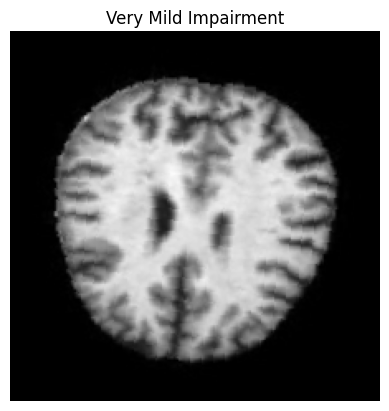

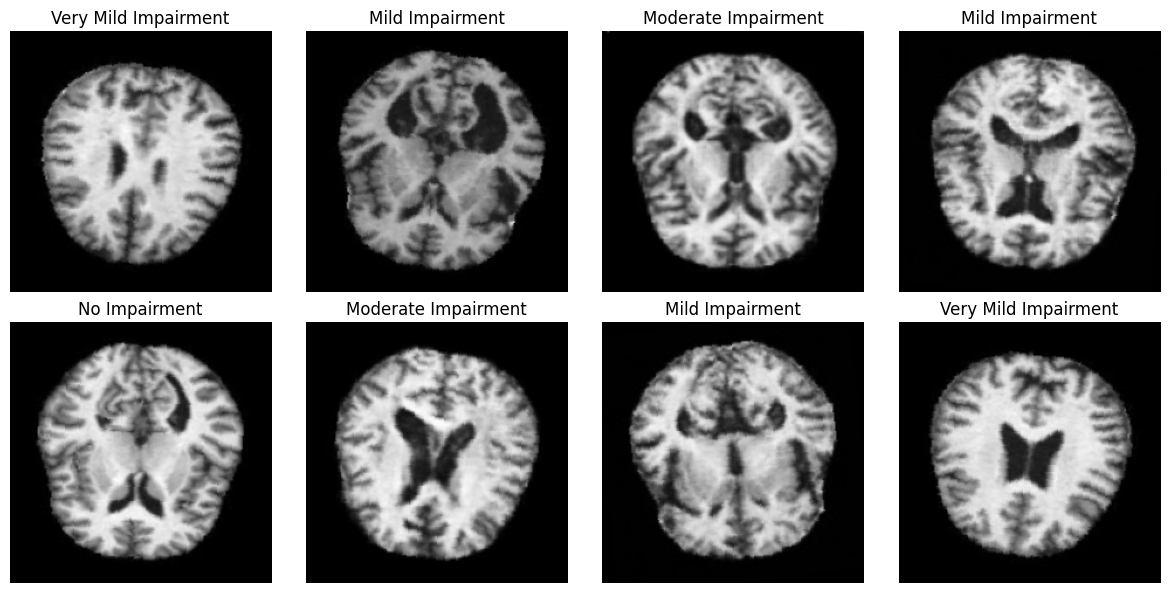

In [8]:
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1,2,0))
plt.title(train_data.classes[labels[0]])
plt.axis('off')
plt.show()
fig, axes = plt.subplots(2, 4, figsize=(12,6))
axes = axes.flatten()

for img, ax, label in zip(images, axes, labels):
    ax.imshow(img.permute(1,2,0))
    ax.set_title(train_data.classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [21]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*54*54, 128)
        self.fc2 = nn.Linear(128, 4)  # 4 classes
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [22]:
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

epochs = 5
for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0
    running_loss = 0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_losses.append(running_loss/len(train_loader))
    train_accuracies.append(100 * correct/total)


In [24]:
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    test_losses.append(val_loss/len(test_loader))
    test_accuracies.append(100 * val_correct/val_total)

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Acc: {train_accuracies[-1]:.2f}%, Test Acc: {test_accuracies[-1]:.2f}%")


Epoch 5/5, Train Acc: 83.75%, Test Acc: 66.07%


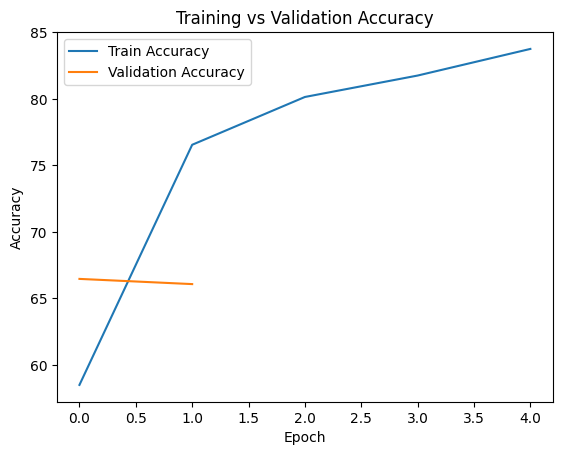

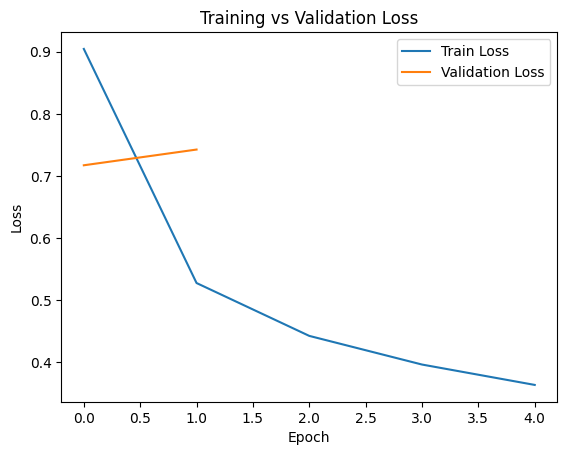

In [25]:
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [26]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [27]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=train_data.classes))


                      precision    recall  f1-score   support

     Mild Impairment       0.50      0.82      0.62       179
 Moderate Impairment       0.90      0.75      0.82        12
       No Impairment       0.85      0.63      0.72       640
Very Mild Impairment       0.60      0.68      0.64       448

            accuracy                           0.67      1279
           macro avg       0.71      0.72      0.70      1279
        weighted avg       0.72      0.67      0.68      1279



Numeric Confusion Matrix Output:

[[146   0   3  30]
 [  0   9   0   3]
 [ 72   0 401 167]
 [ 75   1  67 305]]


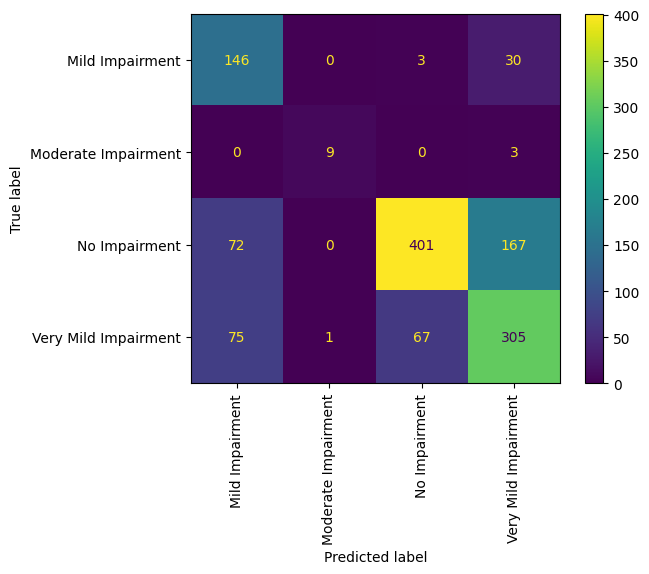

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
print("Numeric Confusion Matrix Output:\n")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot(xticks_rotation='vertical')
plt.show()
